# Two-device series IV: cell-level PVSPICE vs module-level SDM SPICE

This notebook compares two simulations for two devices/modules in series:

1. Cell-level PVSPICE simulation. Each module is expanded into cells_per_device cells and simulated with module_to_netlist. The two module IV curves are combined in series by common current.

2. Module-level single-diode-model simulation. Each module is represented directly using the shared SDM parameters il, io, rs, rsh, and nNsVth. The two module-level SDM devices are connected in series in one ngspice circuit.

The points of interest are currents from 1.0 A to 6.0 A in 0.5 A steps.

In [1]:
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Move to project root, following the style used in the uploaded PVSPICE example notebook.
# If this is not correct for your environment, comment these lines and set project_root manually.
project_root = Path.cwd().parents[1]
os.chdir(project_root)

from pvcracks.pvspice.spice_tools import module_to_netlist
from pvcracks.pvspice.spice_tools import ngpsice_read_voltage_current_modules

spicepath = os.environ.get(
    'NGSPICE_PATH',
    r'/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice'
)

spice_root = Path('docs/data/two_series_reverse_bias_cell_vs_module')
spice_root.mkdir(parents=True, exist_ok=True)

print('project_root:', Path.cwd())
print('ngspice path:', spicepath)
print('spice_root:', spice_root)


project_root: /home/nrjost/githome/pvcracks
ngspice path: /home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice
spice_root: docs/data/two_series_reverse_bias_cell_vs_module


## Input SDM parameters

The two rows represent the two modules connected in series.

In [2]:
il = np.array([[6.], [4.]])          # A
io = np.array([[1e-9], [5e-8]])      # A
rs = np.array([[0.5], [0.7]])        # ohm
rsh = np.array([[2000.], [1200.]])   # ohm
nNsVth = np.array([[2.5], [2.9]])    # V, module-level lumped diode voltage

# Module-level reverse-voltage limit.
v_reverse_limit_module = -5.0

# Number of cells used to expand each module in the cell-level PVSPICE simulation.
cells_per_module = 60

# Cell-level breakdown voltage magnitude for the cell-level PVSPICE simulation.
breakdown_voltage_cell = abs(v_reverse_limit_module) / cells_per_module

# Module-level breakdown voltage magnitude for the module-level SDM simulation.
breakdown_voltage_module = abs(v_reverse_limit_module)

# Large bypass breakdown to avoid practical bypass action.
v_bypass = 1.0e6

T_C = 25.0

IL_module = il.ravel().astype(float)
I0_module = io.ravel().astype(float)
RS_module = rs.ravel().astype(float)
RSH_module = rsh.ravel().astype(float)
nNsVth_module = nNsVth.ravel().astype(float)

n_modules = len(IL_module)

k_B = 1.380649e-23
q_e = 1.602176634e-19
T_K = T_C + 273.15
Vth = k_B * T_K / q_e

# Cell-level diode ideality factors for cell-level PVSPICE runs.
N_cell = nNsVth_module / (cells_per_module * Vth)

# Module-level diode ideality factors for module-level SDM run.
N_module = nNsVth_module / Vth

# Points of interest: 1.0, 1.5, 2.0, ..., 6.0 A.
requested_currents = np.arange(1.0, 6.0 + 1e-12, 0.5)

module_params = pd.DataFrame({
    'module': np.arange(n_modules),
    'IL_module_A': IL_module,
    'I0_module_A': I0_module,
    'Rs_module_ohm': RS_module,
    'Rsh_module_ohm': RSH_module,
    'nNsVth_module_V': nNsVth_module,
    'N_module_spice': N_module,
    'N_cell_spice': N_cell,
    'cells_per_module': cells_per_module,
    'reverse_voltage_limit_module_V': v_reverse_limit_module,
    'breakdown_voltage_module_V': breakdown_voltage_module,
    'breakdown_voltage_cell_V': breakdown_voltage_cell
})

display(module_params)
print('Thermal voltage:', Vth)
print('Requested currents:', requested_currents)


,module,IL_module_A,I0_module_A,Rs_module_ohm,Rsh_module_ohm,nNsVth_module_V,N_module_spice,N_cell_spice,cells_per_module,reverse_voltage_limit_module_V,breakdown_voltage_module_V,breakdown_voltage_cell_V
0,0,6.0,1.000000e-09,0.5,2000.0,2.5,97.304361,1.621739,60,-5.0,5.0,0.083333
1,1,4.0,5.000000e-08,0.7,1200.0,2.9,112.873059,1.881218,60,-5.0,5.0,0.083333


Thermal voltage: 0.02569257912108585
Requested currents: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]


## Cell-level parameter table

This table documents the cell-level parameters used by the cell-level PVSPICE simulations.

In [3]:
cell_rows = []

for module_idx in range(n_modules):
    for cell_idx in range(cells_per_module):
        cell_rows.append({
            'module': module_idx,
            'cell_index_within_module': cell_idx,
            'IL_cell_A': IL_module[module_idx],
            'I0_cell_A': I0_module[module_idx],
            'Rs_cell_ohm': RS_module[module_idx] / cells_per_module,
            'Rsh_cell_ohm': RSH_module[module_idx] / cells_per_module,
            'N_cell_spice': N_cell[module_idx],
            'breakdown_voltage_cell_V': breakdown_voltage_cell
        })

cell_params = pd.DataFrame(cell_rows)
display(cell_params.head())
display(cell_params.tail())


,module,cell_index_within_module,IL_cell_A,I0_cell_A,Rs_cell_ohm,Rsh_cell_ohm,N_cell_spice,breakdown_voltage_cell_V
0,0,0,6.0,1.000000e-09,0.008333,33.333333,1.621739,0.083333
1,0,1,6.0,1.000000e-09,0.008333,33.333333,1.621739,0.083333
2,0,2,6.0,1.000000e-09,0.008333,33.333333,1.621739,0.083333
3,0,3,6.0,1.000000e-09,0.008333,33.333333,1.621739,0.083333
4,0,4,6.0,1.000000e-09,0.008333,33.333333,1.621739,0.083333


,module,cell_index_within_module,IL_cell_A,I0_cell_A,Rs_cell_ohm,Rsh_cell_ohm,N_cell_spice,breakdown_voltage_cell_V
115,1,55,4.0,5.000000e-08,0.011667,20.0,1.881218,0.083333
116,1,56,4.0,5.000000e-08,0.011667,20.0,1.881218,0.083333
117,1,57,4.0,5.000000e-08,0.011667,20.0,1.881218,0.083333
118,1,58,4.0,5.000000e-08,0.011667,20.0,1.881218,0.083333
119,1,59,4.0,5.000000e-08,0.011667,20.0,1.881218,0.083333


## Cell-level PVSPICE simulations

Each module is simulated separately as a cell-level PVSPICE module. The module-level IV curves are then combined in series.

In [4]:
cell_level_results = []

for module_idx in range(n_modules):
    print('\n' + '=' * 80)
    print('CELL-LEVEL PVSPICE SIMULATION FOR MODULE', module_idx)
    print('=' * 80)

    module_path = spice_root / f'cell_level_module_{module_idx}'
    module_path.mkdir(parents=True, exist_ok=True)

    circuit_name = 'solar_circuit'
    circuit_file = module_path / f'{circuit_name}.cir'
    log_file = circuit_file.with_suffix('.ngspice.log')

    if circuit_file.exists():
        circuit_file.unlink()
    if log_file.exists():
        log_file.unlink()

    cell_currents = np.full(cells_per_module, IL_module[module_idx], dtype=float)
    series_resistances = np.full(cells_per_module, RS_module[module_idx] / cells_per_module, dtype=float)
    shunt_resistances = np.full(cells_per_module, RSH_module[module_idx] / cells_per_module, dtype=float)

    v_oc_sweep_limit = 80.0

    print('module_path:', module_path)
    print('IL_cell:', IL_module[module_idx])
    print('I0_cell:', I0_module[module_idx])
    print('Rs_cell:', RS_module[module_idx] / cells_per_module)
    print('Rsh_cell:', RSH_module[module_idx] / cells_per_module)
    print('N_cell:', N_cell[module_idx])
    print('breakdown_voltage_cell:', breakdown_voltage_cell)

    circuit_content, halfcut = module_to_netlist(
        path=str(module_path),
        N_s=cells_per_module,
        cell_currents=cell_currents,
        series_resistances=series_resistances,
        shunt_resistances=shunt_resistances,
        ideality_factor=float(N_cell[module_idx]),
        saturation_current=float(I0_module[module_idx]),
        breakdown_voltage=float(breakdown_voltage_cell),
        v_bypass=float(v_bypass),
        v_oc=float(v_oc_sweep_limit),
        TNOM=float(T_C),
        circuit_name=circuit_name,
    )

    if not circuit_file.exists():
        raise FileNotFoundError(f'Expected circuit file was not created: {circuit_file}')

    text = circuit_file.read_text()
    lines = text.splitlines()
    patched_lines = []
    patched = False

    v_sweep_min = 1.2 * v_reverse_limit_module
    v_sweep_max = v_oc_sweep_limit
    v_sweep_step = 0.01

    for line in lines:
        stripped = line.strip()
        lower = stripped.lower()
        if lower.startswith('dc ') or lower.startswith('.dc '):
            parts = stripped.split()
            print('Original sweep line:', line)
            if len(parts) >= 5:
                prefix = parts[0]
                source_name = parts[1]
                new_line = f'{prefix} {source_name} {v_sweep_min:.12g} {v_sweep_max:.12g} {v_sweep_step:.12g}'
                patched_lines.append(new_line)
                patched = True
                print('New sweep line:', new_line)
                continue
        patched_lines.append(line)

    if not patched:
        print('\n'.join(lines[:160]))
        raise RuntimeError(f'No DC sweep line was found for module {module_idx}.')

    circuit_file.write_text('\n'.join(patched_lines) + '\n')

    netlist_text = circuit_file.read_text()
    if '[' in netlist_text or ']' in netlist_text:
        print('\n'.join(netlist_text.splitlines()[:160]))
        raise RuntimeError(f'Module {module_idx} netlist contains array-valued model parameters.')

    cmd = [spicepath, '-b', '-o', str(log_file), str(circuit_file)]
    print('Running:', cmd)
    completed = subprocess.run(cmd, capture_output=True, text=True)
    print('Return code:', completed.returncode)

    if log_file.exists():
        print(log_file.read_text(errors='replace')[-3000:])

    if completed.returncode != 0:
        print('\n'.join(circuit_file.read_text().splitlines()[:220]))
        raise RuntimeError(f'ngspice failed for cell-level module {module_idx}.')

    voltage_spice, current_spice, df_module = ngpsice_read_voltage_current_modules(str(module_path))
    df_module = df_module.copy()

    if not {'V', 'I'}.issubset(df_module.columns):
        display(df_module.head())
        raise ValueError(f'Expected V and I columns for module {module_idx}.')

    if len(df_module) > 0 and np.nanmedian(df_module['I']) < 0:
        df_module['I'] = -df_module['I']

    df_module = df_module.rename(columns={
        'V': f'V_module{module_idx}_cell_level_V',
        'I': f'I_module{module_idx}_cell_level_A'
    })

    df_module = df_module.replace([np.inf, -np.inf], np.nan)
    df_module = df_module.dropna(subset=[f'V_module{module_idx}_cell_level_V', f'I_module{module_idx}_cell_level_A'])
    df_module = df_module.reset_index(drop=True)
    df_module[f'P_module{module_idx}_cell_level_W'] = df_module[f'V_module{module_idx}_cell_level_V'] * df_module[f'I_module{module_idx}_cell_level_A']

    display(df_module.head())
    display(df_module.tail())

    cell_level_results.append({
        'module': module_idx,
        'path': module_path,
        'circuit_file': circuit_file,
        'log_file': log_file,
        'df': df_module
    })

print('\nFinished all cell-level PVSPICE simulations.')



CELL-LEVEL PVSPICE SIMULATION FOR MODULE 0
module_path: docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_0
IL_cell: 6.0
I0_cell: 1e-09
Rs_cell: 0.008333333333333333
Rsh_cell: 33.333333333333336
N_cell: 1.6217393540094585
breakdown_voltage_cell: 0.08333333333333333
All series interconnection of 60 solar cells
Original sweep line: dc V1 0 81.0 0.1
New sweep line: dc V1 -6 80 0.01
Running: ['/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice', '-b', '-o', 'docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_0/solar_circuit.ngspice.log', 'docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_0/solar_circuit.cir']
Return code: 0

Note: No compatibility mode selected!


Circuit: 

Doing analysis at TEMP = 25.000000 and TNOM = 25.000000

Note: v1: has no value, DC 0 assumed

No. of Data Rows : 8600

Error: no such function as i,
    or i(d1) is not available.
ASCII raw file "docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_0/solar

,V_module0_cell_level_V,I_module0_cell_level_A,P_module0_cell_level_W
0,-6.00,6.412232e+26,-3.847339e+27
1,-5.99,5.632020e+26,-3.373580e+27
2,-5.98,4.946741e+26,-2.958151e+27
3,-5.97,4.344844e+26,-2.593872e+27
4,-5.96,3.816182e+26,-2.274445e+27


,V_module0_cell_level_V,I_module0_cell_level_A,P_module0_cell_level_W
8595,79.95,-37.431333,-2992.635061
8596,79.96,-37.449267,-2994.443405
8597,79.97,-37.467202,-2996.252169
8598,79.98,-37.485138,-2998.061352
8599,79.99,-37.503075,-2999.870956



CELL-LEVEL PVSPICE SIMULATION FOR MODULE 1
module_path: docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_1
IL_cell: 4.0
I0_cell: 5e-08
Rs_cell: 0.011666666666666665
Rsh_cell: 20.0
N_cell: 1.881217650650972
breakdown_voltage_cell: 0.08333333333333333
All series interconnection of 60 solar cells
Original sweep line: dc V1 0 81.0 0.1
New sweep line: dc V1 -6 80 0.01
Running: ['/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice', '-b', '-o', 'docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_1/solar_circuit.ngspice.log', 'docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_1/solar_circuit.cir']
Return code: 0

Note: No compatibility mode selected!


Circuit: 

Doing analysis at TEMP = 25.000000 and TNOM = 25.000000

Note: v1: has no value, DC 0 assumed

No. of Data Rows : 8600

Error: no such function as i,
    or i(d1) is not available.
ASCII raw file "docs/data/two_series_reverse_bias_cell_vs_module/cell_level_module_1/solar_circuit.out"
A

,V_module1_cell_level_V,I_module1_cell_level_A,P_module1_cell_level_W
0,-6.00,6.412232e+26,-3.847339e+27
1,-5.99,5.632020e+26,-3.373580e+27
2,-5.98,4.946741e+26,-2.958151e+27
3,-5.97,4.344844e+26,-2.593872e+27
4,-5.96,3.816182e+26,-2.274445e+27


,V_module1_cell_level_V,I_module1_cell_level_A,P_module1_cell_level_W
8595,79.95,-29.968382,-2395.972103
8596,79.96,-29.981113,-2397.289770
8597,79.97,-29.993844,-2398.607732
8598,79.98,-30.006577,-2399.925991
8599,79.99,-30.019309,-2401.244546



Finished all cell-level PVSPICE simulations.


## Combine cell-level module curves in series

For modules in series, current is common and voltages add.

In [5]:
df_module0_cell = cell_level_results[0]['df']
df_module1_cell = cell_level_results[1]['df']

df0_cell_curve = df_module0_cell[['I_module0_cell_level_A', 'V_module0_cell_level_V']].copy()
df0_cell_curve = df0_cell_curve.replace([np.inf, -np.inf], np.nan).dropna()
df0_cell_curve = df0_cell_curve.sort_values('I_module0_cell_level_A')
df0_cell_curve = df0_cell_curve.groupby('I_module0_cell_level_A', as_index=False)['V_module0_cell_level_V'].mean()

df1_cell_curve = df_module1_cell[['I_module1_cell_level_A', 'V_module1_cell_level_V']].copy()
df1_cell_curve = df1_cell_curve.replace([np.inf, -np.inf], np.nan).dropna()
df1_cell_curve = df1_cell_curve.sort_values('I_module1_cell_level_A')
df1_cell_curve = df1_cell_curve.groupby('I_module1_cell_level_A', as_index=False)['V_module1_cell_level_V'].mean()

I0_cell = df0_cell_curve['I_module0_cell_level_A'].to_numpy(dtype=float)
V0_cell = df0_cell_curve['V_module0_cell_level_V'].to_numpy(dtype=float)
I1_cell = df1_cell_curve['I_module1_cell_level_A'].to_numpy(dtype=float)
V1_cell = df1_cell_curve['V_module1_cell_level_V'].to_numpy(dtype=float)

i_max_cell = min(I0_cell.max(), I1_cell.max(), 6.2)

if i_max_cell < 6.0:
    print('Module 0 current range:', I0_cell.min(), 'to', I0_cell.max())
    print('Module 1 current range:', I1_cell.min(), 'to', I1_cell.max())
    raise RuntimeError('Cell-level common current range does not cover 1 to 6 A.')

I_cell_series = np.linspace(0.0, i_max_cell, 10001)
V0_cell_series = np.interp(I_cell_series, I0_cell, V0_cell)
V1_cell_series = np.interp(I_cell_series, I1_cell, V1_cell)
V_cell_series = V0_cell_series + V1_cell_series
P_cell_series = I_cell_series * V_cell_series

df_cell_series = pd.DataFrame({
    'I_A': I_cell_series,
    'V_string_cell_level_V': V_cell_series,
    'P_string_cell_level_W': P_cell_series,
    'V_module0_cell_level_V': V0_cell_series,
    'V_module1_cell_level_V': V1_cell_series
})

display(df_cell_series.head())
display(df_cell_series.tail())


,I_A,V_string_cell_level_V,P_string_cell_level_W,V_module0_cell_level_V,V_module1_cell_level_V
0,0.00000,109.016590,0.000000,56.275791,52.740799
1,0.00062,109.015133,0.067589,56.275222,52.739911
2,0.00124,109.013675,0.135177,56.274652,52.739022
3,0.00186,109.012216,0.202763,56.274083,52.738134
4,0.00248,109.010758,0.270347,56.273513,52.737245


,I_A,V_string_cell_level_V,P_string_cell_level_W,V_module0_cell_level_V,V_module1_cell_level_V
9996,6.19752,-2.420521,-15.001226,-1.117583,-1.302938
9997,6.19814,-2.420791,-15.004402,-1.117832,-1.302959
9998,6.19876,-2.421061,-15.007579,-1.118081,-1.302981
9999,6.19938,-2.421332,-15.010756,-1.118330,-1.303002
10000,6.20000,-2.421602,-15.013933,-1.118579,-1.303023


## Module-level SDM simulation

This simulation uses the shared module-level SDM parameters directly for each module.

In [6]:
module_level_path = spice_root / 'module_level_sdm'
module_level_path.mkdir(parents=True, exist_ok=True)

module_level_circuit_file = module_level_path / 'two_module_sdm_series.cir'
module_level_raw_file = module_level_path / 'two_module_sdm_series_wrdata.txt'
module_level_log_file = module_level_circuit_file.with_suffix('.ngspice.log')

# Remove old files so stale partial results are not reused.
for f in [module_level_circuit_file, module_level_raw_file, module_level_log_file]:
    if f.exists():
        f.unlink()

# Important:
# Do NOT include BV/IBV in these diode models for this comparison.
# The requested reverse-bias model is a vertical voltage cap at -5 V/module,
# which is applied later in Python in the module-level-read cell.
#
# If BV/IBV is included here, ngspice may stop near the reverse breakdown
# region and fail to sweep to 6 A.

module_level_sweep_current_max = 10.0
module_level_sweep_current_step = 0.001

netlist = f'''
* Two module-level SDM models in series
* Ordinary one-diode model is solved by ngspice.
* Vertical reverse-bias cap at -5 V/module is applied in Python post-processing.

.option abstol=1e-12 reltol=1e-8 chgtol=1e-14
.temp {T_C:.8g}

* Current source sweeps string current from out to ground
Iload out 0 DC 0

* Module 0: positive terminal out, negative terminal mid
Rser0 out d0 {RS_module[0]:.16g}
D0 d0 mid D0MOD
Rsh0 d0 mid {RSH_module[0]:.16g}
Iph0 mid d0 DC {IL_module[0]:.16g}

* Module 1: positive terminal mid, negative terminal ground
Rser1 mid d1 {RS_module[1]:.16g}
D1 d1 0 D1MOD
Rsh1 d1 0 {RSH_module[1]:.16g}
Iph1 0 d1 DC {IL_module[1]:.16g}

* Module-level diode models from shared SDM parameters.
* No BV/IBV here. Reverse-voltage vertical cap is applied after reading results.
.model D0MOD D(IS={I0_module[0]:.16g} N={N_module[0]:.16g})
.model D1MOD D(IS={I0_module[1]:.16g} N={N_module[1]:.16g})

.control
set filetype=ascii
dc Iload 0 {module_level_sweep_current_max:.16g} {module_level_sweep_current_step:.16g}
wrdata {module_level_raw_file.as_posix()} v(out) v(out,mid) v(mid)
quit
.endc

.end
'''.strip() + '\n'

module_level_circuit_file.write_text(netlist)

print('Wrote module-level circuit file:', module_level_circuit_file)
print('Expected raw output file:', module_level_raw_file)
print('Sweep current max:', module_level_sweep_current_max)
print('Sweep current step:', module_level_sweep_current_step)
print(netlist)

Wrote module-level circuit file: docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm/two_module_sdm_series.cir
Expected raw output file: docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm/two_module_sdm_series_wrdata.txt
Sweep current max: 10.0
Sweep current step: 0.001
* Two module-level SDM models in series
* Ordinary one-diode model is solved by ngspice.
* Vertical reverse-bias cap at -5 V/module is applied in Python post-processing.

.option abstol=1e-12 reltol=1e-8 chgtol=1e-14
.temp 25

* Current source sweeps string current from out to ground
Iload out 0 DC 0

* Module 0: positive terminal out, negative terminal mid
Rser0 out d0 0.5
D0 d0 mid D0MOD
Rsh0 d0 mid 2000
Iph0 mid d0 DC 6

* Module 1: positive terminal mid, negative terminal ground
Rser1 mid d1 0.7
D1 d1 0 D1MOD
Rsh1 d1 0 1200
Iph1 0 d1 DC 4

* Module-level diode models from shared SDM parameters.
* No BV/IBV here. Reverse-voltage vertical cap is applied after reading results.
.model D0MOD 

In [7]:
cmd = [
    spicepath,
    '-b',
    '-o',
    str(module_level_log_file),
    str(module_level_circuit_file)
]

print('Running module-level ngspice command:')
print(cmd)

completed = subprocess.run(cmd, capture_output=True, text=True)

print('Return code:', completed.returncode)
print('\n--- Python-captured STDOUT ---')
print(completed.stdout)
print('\n--- Python-captured STDERR ---')
print(completed.stderr)

if module_level_log_file.exists():
    print('\n--- Module-level ngspice log tail ---')
    print(module_level_log_file.read_text(errors='replace')[-3000:])

if completed.returncode != 0:
    print('\n'.join(module_level_circuit_file.read_text().splitlines()[:220]))
    raise RuntimeError('ngspice failed for module-level SDM simulation.')

if not module_level_raw_file.exists():
    raise FileNotFoundError(f'Module-level raw output file was not created: {module_level_raw_file}')

print('Module-level ngspice run finished.')


Running module-level ngspice command:
['/home/nrjost/.conda/envs/pyhpc_spice/bin/ngspice', '-b', '-o', 'docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm/two_module_sdm_series.ngspice.log', 'docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm/two_module_sdm_series.cir']
Return code: 0

--- Python-captured STDOUT ---
******
** ngspice-41 : Circuit level simulation program
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2023, The ngspice team.
** Please get your ngspice manual from https://ngspice.sourceforge.io/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Mon Mar 25 19:05:40 UTC 2024
******

Batch mode

Comments and warnings go to log-file: docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm/two_module_sdm_series.ngspice.log



--- Python-captured STDERR ---


--- Module-level ngspice log tail ---

Note: No compatibil

In [8]:
raw = np.loadtxt(module_level_raw_file)

if raw.ndim == 1:
    raw = raw.reshape(1, -1)

print('Module-level raw shape:', raw.shape)

if raw.shape[1] != 6:
    raise ValueError(f'Expected 6 columns from wrdata, got {raw.shape[1]}')

df_module_level = pd.DataFrame({
    'I_A': raw[:, 0],
    'V_string_module_level_uncapped_V': raw[:, 1],
    'V_module0_module_level_uncapped_V': raw[:, 3],
    'V_module1_module_level_uncapped_V': raw[:, 5]
})

# Apply vertical reverse-bias voltage limit at the module level.
df_module_level['V_module0_module_level_V'] = np.maximum(
    df_module_level['V_module0_module_level_uncapped_V'],
    v_reverse_limit_module
)

df_module_level['V_module1_module_level_V'] = np.maximum(
    df_module_level['V_module1_module_level_uncapped_V'],
    v_reverse_limit_module
)

df_module_level['V_string_module_level_V'] = (
    df_module_level['V_module0_module_level_V']
    + df_module_level['V_module1_module_level_V']
)

df_module_level['P_string_module_level_W'] = (
    df_module_level['I_A'] * df_module_level['V_string_module_level_V']
)

df_module_level = df_module_level.sort_values('I_A')
df_module_level = df_module_level.groupby('I_A', as_index=False).mean(numeric_only=True)

display(df_module_level.head())
display(df_module_level.tail())

print('Module-level current range:', df_module_level['I_A'].min(), 'to', df_module_level['I_A'].max())
print('Module-level string voltage range:', df_module_level['V_string_module_level_V'].min(), 'to', df_module_level['V_string_module_level_V'].max())


Module-level raw shape: (10001, 6)


,I_A,V_string_module_level_uncapped_V,V_module0_module_level_uncapped_V,V_module1_module_level_uncapped_V,V_module0_module_level_V,V_module1_module_level_V,V_string_module_level_V,P_string_module_level_W
0,0.000,109.032409,56.283702,52.748706,56.283702,52.748706,109.032409,0.000000
1,0.001,109.030057,56.282784,52.747274,56.282784,52.747274,109.030057,0.109030
2,0.002,109.027706,56.281865,52.745841,56.281865,52.745841,109.027706,0.218055
3,0.003,109.025354,56.280946,52.744408,56.280946,52.744408,109.025354,0.327076
4,0.004,109.023002,56.280028,52.742974,56.280028,52.742974,109.023002,0.436092


,I_A,V_string_module_level_uncapped_V,V_module0_module_level_uncapped_V,V_module1_module_level_uncapped_V,V_module0_module_level_V,V_module1_module_level_V,V_string_module_level_V,P_string_module_level_W
9996,9.996,-15199.1951,-7996.99798,-7202.19713,-5.0,-5.0,-10.0,-99.96
9997,9.997,-15202.3963,-7998.99848,-7203.39783,-5.0,-5.0,-10.0,-99.97
9998,9.998,-15205.5975,-8000.99898,-7204.59853,-5.0,-5.0,-10.0,-99.98
9999,9.999,-15208.7987,-8002.99948,-7205.79923,-5.0,-5.0,-10.0,-99.99
10000,10.000,-15211.9999,-8004.99998,-7206.99993,-5.0,-5.0,-10.0,-100.00


Module-level current range: 0.0 to 10.0
Module-level string voltage range: -10.0 to 109.0324086


## Points of interest: 1 A to 6 A in 0.5 A steps

This table contains all requested current points for both methods.

In [9]:
print("requested current range:", requested_currents.min(), "to", requested_currents.max())

print("cell-level current range:",
      df_cell_series["I_A"].min(),
      "to",
      df_cell_series["I_A"].max())

print("module-level current range:",
      df_module_level["I_A"].min(),
      "to",
      df_module_level["I_A"].max())

display(df_module_level.head())
display(df_module_level.tail())

requested current range: 1.0 to 6.0
cell-level current range: 0.0 to 6.2
module-level current range: 0.0 to 10.0


,I_A,V_string_module_level_uncapped_V,V_module0_module_level_uncapped_V,V_module1_module_level_uncapped_V,V_module0_module_level_V,V_module1_module_level_V,V_string_module_level_V,P_string_module_level_W
0,0.000,109.032409,56.283702,52.748706,56.283702,52.748706,109.032409,0.000000
1,0.001,109.030057,56.282784,52.747274,56.282784,52.747274,109.030057,0.109030
2,0.002,109.027706,56.281865,52.745841,56.281865,52.745841,109.027706,0.218055
3,0.003,109.025354,56.280946,52.744408,56.280946,52.744408,109.025354,0.327076
4,0.004,109.023002,56.280028,52.742974,56.280028,52.742974,109.023002,0.436092


,I_A,V_string_module_level_uncapped_V,V_module0_module_level_uncapped_V,V_module1_module_level_uncapped_V,V_module0_module_level_V,V_module1_module_level_V,V_string_module_level_V,P_string_module_level_W
9996,9.996,-15199.1951,-7996.99798,-7202.19713,-5.0,-5.0,-10.0,-99.96
9997,9.997,-15202.3963,-7998.99848,-7203.39783,-5.0,-5.0,-10.0,-99.97
9998,9.998,-15205.5975,-8000.99898,-7204.59853,-5.0,-5.0,-10.0,-99.98
9999,9.999,-15208.7987,-8002.99948,-7205.79923,-5.0,-5.0,-10.0,-99.99
10000,10.000,-15211.9999,-8004.99998,-7206.99993,-5.0,-5.0,-10.0,-100.00


In [10]:
I_cell = df_cell_series['I_A'].to_numpy(dtype=float)
V_cell = df_cell_series['V_string_cell_level_V'].to_numpy(dtype=float)

I_module = df_module_level['I_A'].to_numpy(dtype=float)
V_module = df_module_level['V_string_module_level_V'].to_numpy(dtype=float)

if requested_currents.min() < I_cell.min() or requested_currents.max() > I_cell.max():
    raise RuntimeError('Requested currents are outside the cell-level simulation range.')

if requested_currents.min() < I_module.min() or requested_currents.max() > I_module.max():
    raise RuntimeError('Requested currents are outside the module-level simulation range.')

V_requested_cell = np.interp(requested_currents, I_cell, V_cell)
V_requested_module = np.interp(requested_currents, I_module, V_module)

V_requested_cell_m0 = np.interp(
    requested_currents,
    I_cell,
    df_cell_series['V_module0_cell_level_V'].to_numpy(dtype=float)
)

V_requested_cell_m1 = np.interp(
    requested_currents,
    I_cell,
    df_cell_series['V_module1_cell_level_V'].to_numpy(dtype=float)
)

V_requested_module_m0 = np.interp(
    requested_currents,
    I_module,
    df_module_level['V_module0_module_level_V'].to_numpy(dtype=float)
)

V_requested_module_m1 = np.interp(
    requested_currents,
    I_module,
    df_module_level['V_module1_module_level_V'].to_numpy(dtype=float)
)

points_of_interest = pd.DataFrame({
    'I_A': requested_currents,
    'V_string_cell_level_V': V_requested_cell,
    'V_module0_cell_level_V': V_requested_cell_m0,
    'V_module1_cell_level_V': V_requested_cell_m1,
    'P_string_cell_level_W': requested_currents * V_requested_cell,
    'V_string_module_level_V': V_requested_module,
    'V_module0_module_level_V': V_requested_module_m0,
    'V_module1_module_level_V': V_requested_module_m1,
    'P_string_module_level_W': requested_currents * V_requested_module,
    'delta_V_cell_minus_module_V': V_requested_cell - V_requested_module
})

display(points_of_interest)


,I_A,V_string_cell_level_V,V_module0_cell_level_V,V_module1_cell_level_V,P_string_cell_level_W,V_string_module_level_V,V_module0_module_level_V,V_module1_module_level_V,P_string_module_level_W,delta_V_cell_minus_module_V
0,1.0,106.514197,55.317746,51.196451,106.514197,106.530014,55.325657,51.204358,106.530014,-0.015817
1,1.5,105.112611,54.802859,50.309752,157.668916,105.128426,54.810769,50.317656,157.692638,-0.015815
2,2.0,103.557346,54.256553,49.300793,207.114692,103.573159,54.264463,49.308696,207.146318,-0.015813
3,2.5,101.767353,53.670361,48.096992,254.418383,101.783163,53.678270,48.104893,254.457908,-0.015810
4,3.0,99.564459,53.031850,46.532609,298.693376,99.580263,53.039760,46.540503,298.740788,-0.015804
5,3.5,96.380167,52.321689,44.058478,337.330583,96.395949,52.329598,44.066351,337.385820,-0.015782
6,4.0,50.757466,51.507344,-0.749878,203.029865,48.715253,51.515253,-2.800000,194.861013,2.042213
7,4.5,49.338361,50.527434,-1.189074,222.022623,45.535342,50.535342,-5.000000,204.909038,3.803019
8,5.0,48.000287,49.242614,-1.242327,240.001435,44.250519,49.250519,-5.000000,221.252595,3.749768
9,5.5,45.923668,47.197181,-1.273514,252.580172,42.205076,47.205076,-5.000000,232.127920,3.718591


## Plots

The first plot is the cell-level simulation. The second plot is the module-level SDM simulation. The third plot overlays both simulations.

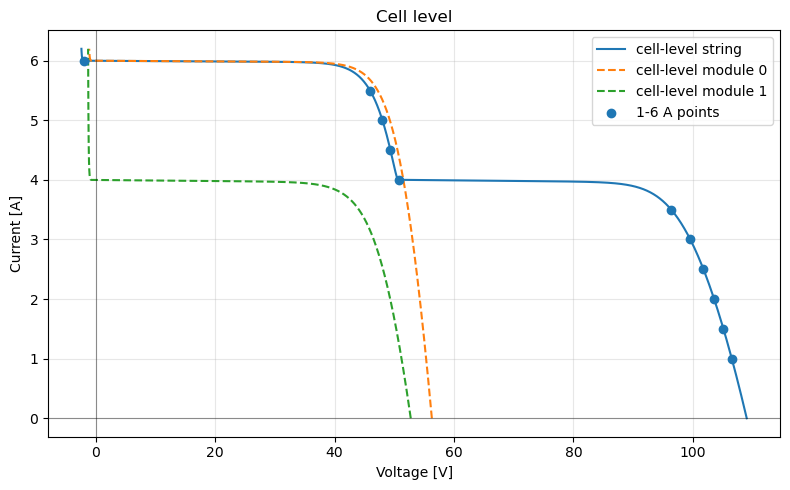

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_cell_series['V_string_cell_level_V'],
    df_cell_series['I_A'],
    label='cell-level string'
)

ax.plot(
    df_cell_series['V_module0_cell_level_V'],
    df_cell_series['I_A'],
    '--',
    label='cell-level module 0'
)

ax.plot(
    df_cell_series['V_module1_cell_level_V'],
    df_cell_series['I_A'],
    '--',
    label='cell-level module 1'
)

ax.scatter(V_requested_cell, requested_currents, zorder=3, label='1-6 A points')

ax.axvline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.axhline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Voltage [V]')
ax.set_ylabel('Current [A]')
ax.set_title('Cell level')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


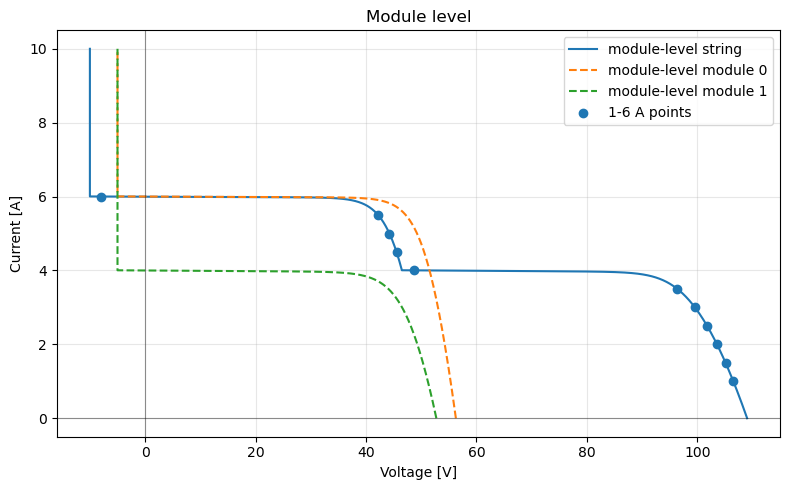

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_module_level['V_string_module_level_V'],
    df_module_level['I_A'],
    label='module-level string'
)

ax.plot(
    df_module_level['V_module0_module_level_V'],
    df_module_level['I_A'],
    '--',
    label='module-level module 0'
)

ax.plot(
    df_module_level['V_module1_module_level_V'],
    df_module_level['I_A'],
    '--',
    label='module-level module 1'
)

ax.scatter(V_requested_module, requested_currents, zorder=3, label='1-6 A points')

ax.axvline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.axhline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Voltage [V]')
ax.set_ylabel('Current [A]')
ax.set_title('Module level')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


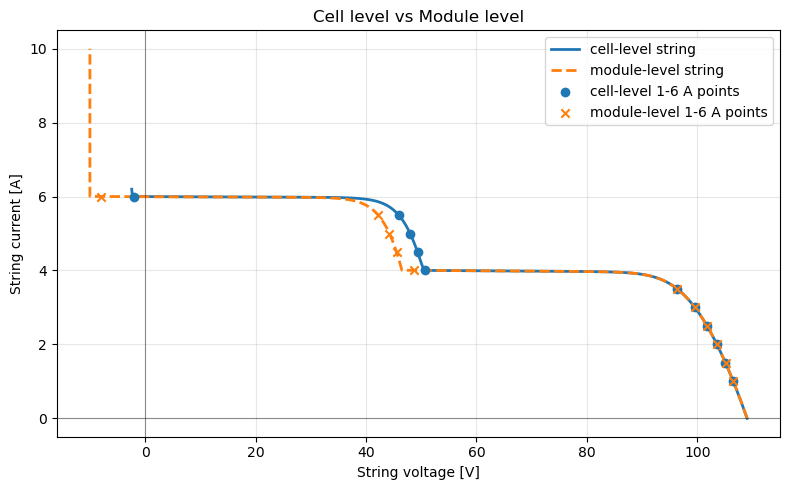

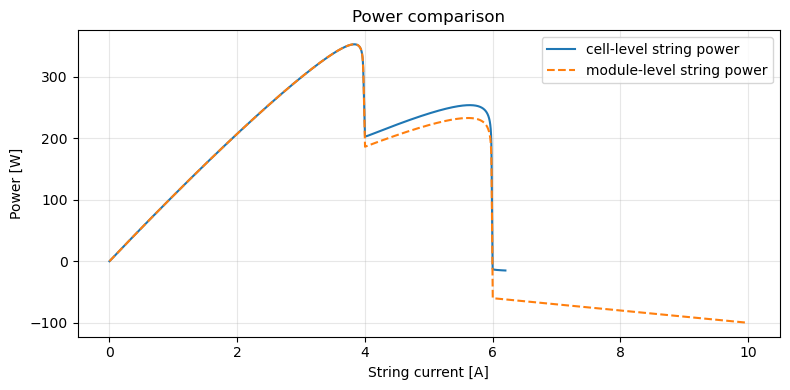

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_cell_series['V_string_cell_level_V'],
    df_cell_series['I_A'],
    label='cell-level string',
    linewidth=2
)

ax.plot(
    df_module_level['V_string_module_level_V'],
    df_module_level['I_A'],
    '--',
    label='module-level string',
    linewidth=2
)

ax.scatter(V_requested_cell, requested_currents, zorder=3, label='cell-level 1-6 A points')
ax.scatter(V_requested_module, requested_currents, marker='x', zorder=3, label='module-level 1-6 A points')

ax.axvline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.axhline(0.0, color='k', linewidth=0.8, alpha=0.4)
ax.set_xlabel('String voltage [V]')
ax.set_ylabel('String current [A]')
ax.set_title('Cell level vs Module level')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    df_cell_series['I_A'],
    df_cell_series['P_string_cell_level_W'],
    label='cell-level string power'
)

ax.plot(
    df_module_level['I_A'],
    df_module_level['P_string_module_level_W'],
    '--',
    label='module-level string power'
)

ax.set_xlabel('String current [A]')
ax.set_ylabel('Power [W]')
ax.set_title('Power comparison')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Save results

This saves the raw cell-level module curves, combined cell-level string curve, module-level SDM curve, points of interest, and parameter tables.

In [14]:
module0_cell_file = spice_root / 'module0_cell_level_curve.csv'
module1_cell_file = spice_root / 'module1_cell_level_curve.csv'
cell_series_file = spice_root / 'cell_level_series_curve.csv'
module_level_file = spice_root / 'module_level_sdm_series_curve.csv'
points_file = spice_root / 'points_of_interest_1_to_6A.csv'
cell_params_file = spice_root / 'cell_parameters.csv'
module_params_file = spice_root / 'module_parameters.csv'

df_module0_cell.to_csv(module0_cell_file, index=False)
df_module1_cell.to_csv(module1_cell_file, index=False)
df_cell_series.to_csv(cell_series_file, index=False)
df_module_level.to_csv(module_level_file, index=False)
points_of_interest.to_csv(points_file, index=False)
cell_params.to_csv(cell_params_file, index=False)
module_params.to_csv(module_params_file, index=False)

print('Wrote:')
print(module0_cell_file)
print(module1_cell_file)
print(cell_series_file)
print(module_level_file)
print(points_file)
print(cell_params_file)
print(module_params_file)

display(points_of_interest)


Wrote:
docs/data/two_series_reverse_bias_cell_vs_module/module0_cell_level_curve.csv
docs/data/two_series_reverse_bias_cell_vs_module/module1_cell_level_curve.csv
docs/data/two_series_reverse_bias_cell_vs_module/cell_level_series_curve.csv
docs/data/two_series_reverse_bias_cell_vs_module/module_level_sdm_series_curve.csv
docs/data/two_series_reverse_bias_cell_vs_module/points_of_interest_1_to_6A.csv
docs/data/two_series_reverse_bias_cell_vs_module/cell_parameters.csv
docs/data/two_series_reverse_bias_cell_vs_module/module_parameters.csv


,I_A,V_string_cell_level_V,V_module0_cell_level_V,V_module1_cell_level_V,P_string_cell_level_W,V_string_module_level_V,V_module0_module_level_V,V_module1_module_level_V,P_string_module_level_W,delta_V_cell_minus_module_V
0,1.0,106.514197,55.317746,51.196451,106.514197,106.530014,55.325657,51.204358,106.530014,-0.015817
1,1.5,105.112611,54.802859,50.309752,157.668916,105.128426,54.810769,50.317656,157.692638,-0.015815
2,2.0,103.557346,54.256553,49.300793,207.114692,103.573159,54.264463,49.308696,207.146318,-0.015813
3,2.5,101.767353,53.670361,48.096992,254.418383,101.783163,53.678270,48.104893,254.457908,-0.015810
4,3.0,99.564459,53.031850,46.532609,298.693376,99.580263,53.039760,46.540503,298.740788,-0.015804
5,3.5,96.380167,52.321689,44.058478,337.330583,96.395949,52.329598,44.066351,337.385820,-0.015782
6,4.0,50.757466,51.507344,-0.749878,203.029865,48.715253,51.515253,-2.800000,194.861013,2.042213
7,4.5,49.338361,50.527434,-1.189074,222.022623,45.535342,50.535342,-5.000000,204.909038,3.803019
8,5.0,48.000287,49.242614,-1.242327,240.001435,44.250519,49.250519,-5.000000,221.252595,3.749768
9,5.5,45.923668,47.197181,-1.273514,252.580172,42.205076,47.205076,-5.000000,232.127920,3.718591
